# Airline Flight Delay Prediction — End-to-End Walkthrough

This notebook walks through the full ML system in `src/airline_delay/` and `api/`,
step by step, so you can see the data, the intermediate outputs, and the final
model and API in action.

It **reuses the actual project code** (the same modules used by
`python -m src.airline_delay.train` and the FastAPI service) rather than
reimplementing the logic — so what you see here is exactly what the production
pipeline does, not a simplified copy.

**Dataset**: [Kaggle Airlines Delay dataset](https://www.kaggle.com/datasets/ulrikthygepedersen/airlines-delay/data)
— 539,382 flights, target `Class` (0 = on-time, 1 = delayed).

**Runtime note**: sections 7 and 8 (model comparison + hyperparameter search)
retrain models on hundreds of thousands of rows and will take roughly
10-15 minutes combined. Each such cell has a ⏱ time estimate in its heading.

**Kernel**: run this notebook with the *"Python (airline-delay venv)"* kernel
(registered via `ipykernel install` into this project's `venv`), or point your
own Jupyter installation at `venv/Scripts/python.exe`.


## 1. Setup

In [1]:
import sys
from pathlib import Path

# Make the project's `src` and `api` packages importable regardless of
# whether Jupyter's working directory is the project root or `notebooks/`.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\development\claude-bde-airline


In [2]:
%matplotlib inline
import json
import time
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.inspection import permutation_importance

from src.airline_delay import config, data, features, predict, reporting
from src.airline_delay.train import (
    build_candidates,
    select_best_candidate,
    quick_tune,
    PARAM_DISTRIBUTIONS,
    SEARCH_SAMPLE_SIZE,
    SEARCH_N_ITER,
    SEARCH_CV,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load & Inspect the Raw Data

`data.load_data()` reads the CSV and validates that all expected columns are
present and there are no null values.

In [3]:
df = data.load_data()
print(f"Shape: {df.shape}")
df.head()

Shape: (539382, 8)


,Flight,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class
0,2313.0,1296.0,141.0,DL,ATL,HOU,1,0
1,6948.0,360.0,146.0,OO,COS,ORD,4,0
2,1247.0,1170.0,143.0,B6,BOS,CLT,3,0
3,31.0,1410.0,344.0,US,OGG,PHX,6,0
4,563.0,692.0,98.0,FL,BMI,ATL,4,0


In [4]:
df.dtypes

Flight         float64
Time           float64
Length         float64
Airline            str
AirportFrom        str
AirportTo          str
DayOfWeek        int64
Class            int64
dtype: object

In [5]:
print("Null values per column:")
df.isna().sum()

Null values per column:


Flight         0
Time           0
Length         0
Airline        0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Class          0
dtype: int64

In [6]:
df.describe()

,Flight,Time,Length,DayOfWeek,Class
count,539382.000000,539382.000000,539382.000000,539382.000000,539382.000000
mean,2427.927988,802.728161,132.202104,3.929666,0.445443
std,2067.431700,278.045546,70.117045,1.914666,0.497015
min,1.000000,10.000000,0.000000,1.000000,0.000000
25%,712.000000,565.000000,81.000000,2.000000,0.000000
50%,1809.000000,795.000000,115.000000,4.000000,0.000000
75%,3745.000000,1035.000000,162.000000,5.000000,1.000000
max,7814.000000,1439.000000,655.000000,7.000000,1.000000


## 3. Exploratory Data Analysis

A quick look at the target balance and how the features relate to delay.

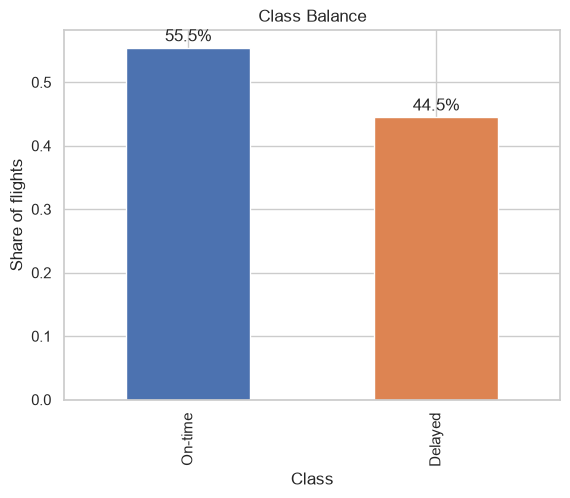

In [7]:
class_counts = df[config.TARGET_COLUMN].value_counts(normalize=True).sort_index()
ax = class_counts.rename(index=config.CLASS_LABELS).plot.bar(color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Share of flights")
ax.set_title("Class Balance")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.show()

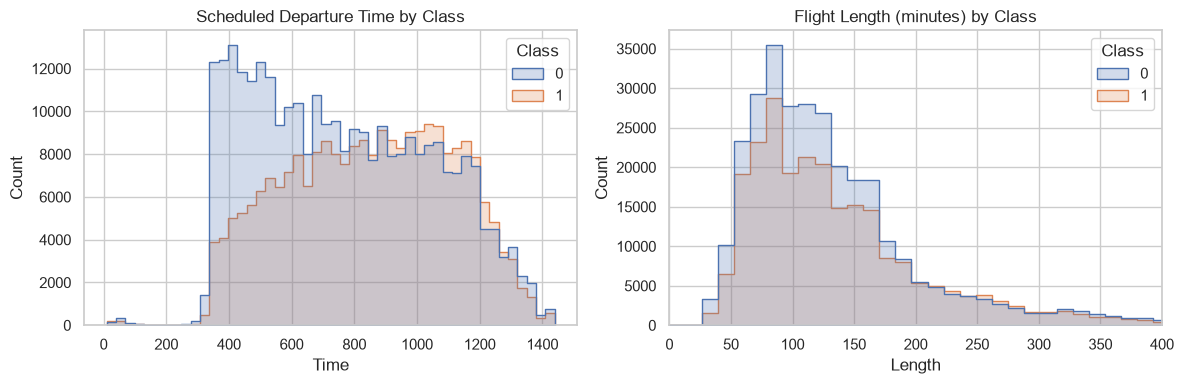

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="Time", hue=config.TARGET_COLUMN, bins=48, element="step", ax=axes[0])
axes[0].set_title("Scheduled Departure Time by Class")
sns.histplot(data=df, x="Length", hue=config.TARGET_COLUMN, bins=50, element="step", ax=axes[1])
axes[1].set_xlim(0, 400)
axes[1].set_title("Flight Length (minutes) by Class")
plt.tight_layout()
plt.show()

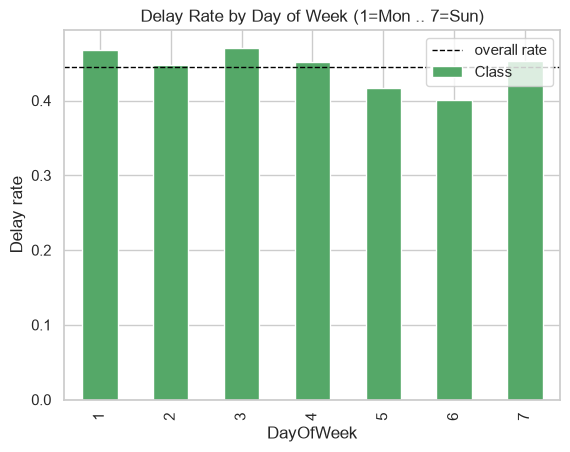

In [9]:
dow_delay_rate = df.groupby("DayOfWeek")[config.TARGET_COLUMN].mean()
ax = dow_delay_rate.plot.bar(color="#55A868")
ax.axhline(df[config.TARGET_COLUMN].mean(), color="black", linestyle="--", linewidth=1, label="overall rate")
ax.set_ylabel("Delay rate")
ax.set_title("Delay Rate by Day of Week (1=Mon .. 7=Sun)")
ax.legend()
plt.show()

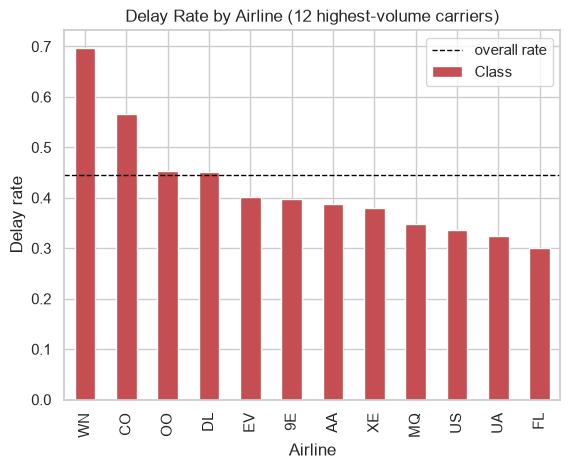

In [10]:
top_airlines = df["Airline"].value_counts().head(12).index
airline_delay_rate = (
    df[df["Airline"].isin(top_airlines)]
    .groupby("Airline")[config.TARGET_COLUMN]
    .mean()
    .sort_values(ascending=False)
)
ax = airline_delay_rate.plot.bar(color="#C44E52")
ax.axhline(df[config.TARGET_COLUMN].mean(), color="black", linestyle="--", linewidth=1, label="overall rate")
ax.set_ylabel("Delay rate")
ax.set_title("Delay Rate by Airline (12 highest-volume carriers)")
ax.legend()
plt.show()

In [11]:
print(f"Distinct airlines: {df['Airline'].nunique()}")
print(f"Distinct AirportFrom: {df['AirportFrom'].nunique()}")
print(f"Distinct AirportTo: {df['AirportTo'].nunique()}")
print(
    "\nThis high cardinality for airports is why the model pipeline uses "
    "ordinal/target encoding instead of one-hot encoding for AirportFrom/AirportTo."
)

Distinct airlines: 18
Distinct AirportFrom: 293
Distinct AirportTo: 293

This high cardinality for airports is why the model pipeline uses ordinal/target encoding instead of one-hot encoding for AirportFrom/AirportTo.


## 4. Train / Validation / Test Split

No date/timestamp column exists (only `DayOfWeek`), so `data.split_data()`
does a **random stratified split** on `Class` — 70% train, 15% validation,
15% test — rather than a time-based split.

In [12]:
train_df, val_df, test_df = data.split_data(df)

print(f"train: {len(train_df):,} rows  ({train_df[config.TARGET_COLUMN].mean():.3f} delay rate)")
print(f"val:   {len(val_df):,} rows  ({val_df[config.TARGET_COLUMN].mean():.3f} delay rate)")
print(f"test:  {len(test_df):,} rows  ({test_df[config.TARGET_COLUMN].mean():.3f} delay rate)")

X_train, y_train = data.get_X_y(train_df)
X_val, y_val = data.get_X_y(val_df)
X_test, y_test = data.get_X_y(test_df)

train: 377,566 rows  (0.445 delay rate)
val:   80,908 rows  (0.445 delay rate)
test:  80,908 rows  (0.445 delay rate)


## 5. Feature Engineering

`features.add_engineered_features()` derives two extra columns from the raw
features before any encoding happens:

- **`IsWeekend`** — 1 if `DayOfWeek` is Saturday/Sunday (6/7), else 0
- **`TimeOfDayBucket`** — `Time` bucketed into night / morning / afternoon / evening

In [13]:
sample_engineered = features.add_engineered_features(X_train.head())
sample_engineered[["Time", "DayOfWeek", "TimeOfDayBucket", "IsWeekend"]]

,Time,DayOfWeek,TimeOfDayBucket,IsWeekend
0,1100.0,3,evening,0
1,1194.0,7,evening,1
2,480.0,5,morning,0
3,680.0,2,morning,0
4,630.0,7,morning,1


## 6. Preprocessing Pipelines

Two different preprocessing strategies feed two different families of model:

- **Baseline (linear)**: one-hot encoding for low-cardinality columns
  (`Airline`, `DayOfWeek`, `TimeOfDayBucket`), cross-fitted **target encoding**
  for the high-cardinality `AirportFrom`/`AirportTo` (293 values each — one-hot
  would blow up dimensionality), and standard scaling for numeric features.
- **Tree models**: everything ordinal-encoded. `HistGradientBoostingClassifier`
  gets told which of those ordinal columns to treat as *native* categorical —
  but only the low-cardinality ones, since its native categorical handling
  caps out at 255 distinct values and airports have 293.

In [14]:
X_train_eng = features.add_engineered_features(X_train)

baseline_preprocessor = features.build_baseline_preprocessor()
baseline_transformed = baseline_preprocessor.fit_transform(X_train_eng.head(1000), y_train.head(1000))
print(f"Baseline preprocessor output shape (on a 1,000-row sample): {baseline_transformed.shape}")

tree_preprocessor, categorical_mask = features.build_tree_preprocessor()
tree_transformed = tree_preprocessor.fit_transform(X_train_eng.head(1000), y_train.head(1000))
print(f"Tree preprocessor output shape (on a 1,000-row sample):     {tree_transformed.shape}")
print(f"Columns treated as native categorical by HistGradientBoosting: {categorical_mask.sum()} of {len(categorical_mask)}")

Baseline preprocessor output shape (on a 1,000-row sample): (1000, 34)
Tree preprocessor output shape (on a 1,000-row sample):     (1000, 8)
Columns treated as native categorical by HistGradientBoosting: 3 of 8


C:\development\claude-bde-airline\venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


## 7. Train & Compare Candidate Models

⏱ **This cell fits three full pipelines on the ~378K-row training set:
Logistic Regression (baseline), Random Forest, and HistGradientBoosting.
It takes roughly 4-6 minutes, dominated by the Random Forest fit.**

Each candidate is scored on the validation set by ROC-AUC and F1.

In [15]:
candidates = build_candidates()
best_name, selection_results = select_best_candidate(candidates, X_train, y_train, X_val, y_val)

results_df = pd.DataFrame(selection_results).T.sort_values("roc_auc", ascending=False)
results_df

[12:38:10] Fitting candidate 'LogisticRegression' on train split...


C:\development\claude-bde-airline\venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


[12:38:15]   LogisticRegression: val ROC-AUC=0.6817, val F1=0.5362


[12:38:15] Fitting candidate 'RandomForestClassifier' on train split...


[12:41:54]   RandomForestClassifier: val ROC-AUC=0.6541, val F1=0.5610


[12:41:54] Fitting candidate 'HistGradientBoostingClassifier' on train split...


[12:42:09]   HistGradientBoostingClassifier: val ROC-AUC=0.7084, val F1=0.5526


[12:42:09] Selected best candidate: HistGradientBoostingClassifier


,roc_auc,f1
HistGradientBoostingClassifier,0.708394,0.552577
LogisticRegression,0.681672,0.536164
RandomForestClassifier,0.654051,0.560969


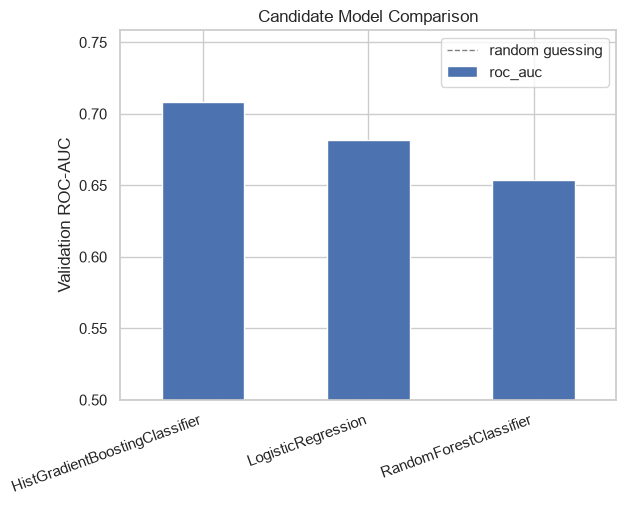

Selected candidate: HistGradientBoostingClassifier


In [16]:
ax = results_df["roc_auc"].plot.bar(color="#4C72B0")
ax.set_ylabel("Validation ROC-AUC")
ax.set_ylim(0.5, max(0.05 + results_df["roc_auc"].max(), 0.75))
ax.set_title("Candidate Model Comparison")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="random guessing")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.show()

print(f"Selected candidate: {best_name}")

## 8. Quick Hyperparameter Tuning

⏱ **This cell runs a `RandomizedSearchCV` (20 parameter combinations × 3-fold
CV = 60 fits) for the winning model on a 100,000-row training subsample. It
takes roughly 5-8 minutes.** This is the "quick tuning" tradeoff — enough to
meaningfully improve on the defaults without an exhaustive multi-hour search.

In [17]:
best_pipeline = candidates[best_name]
print(f"Search space for {best_name}:")
pprint(PARAM_DISTRIBUTIONS[best_name])

best_params = quick_tune(best_name, best_pipeline, X_train, y_train)
best_pipeline.set_params(**best_params)

Search space for HistGradientBoostingClassifier:
{'classifier__l2_regularization': [0, 0.1, 1, 10],
 'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
 'classifier__max_iter': [100, 150, 200, 300],
 'classifier__max_leaf_nodes': [15, 31, 63, 127],
 'classifier__min_samples_leaf': [10, 20, 50, 100]}


[12:42:10] Running quick RandomizedSearchCV for HistGradientBoostingClassifier (n_iter=20, cv=3, sample=100000)...


[12:43:18] Best params: {'classifier__min_samples_leaf': 10, 'classifier__max_leaf_nodes': 63, 'classifier__max_iter': 150, 'classifier__learning_rate': 0.2, 'classifier__l2_regularization': 10} (CV ROC-AUC=0.7002)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Flight','Time','Length',...,'AirportFrom','AirportTo','DayOfWeek']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...002101AB57480>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False


## 9. Refit on Train+Val and Evaluate on the Held-Out Test Set

The tuned pipeline is refit on train+validation combined, then evaluated
**once** on the test set — data it has never influenced any decision on.

In [18]:
X_trainval = pd.concat([X_train, X_val], ignore_index=True)
y_trainval = pd.concat([y_train, y_val], ignore_index=True)

t0 = time.time()
best_pipeline.fit(X_trainval, y_trainval)
print(f"Refit on {len(X_trainval):,} rows in {time.time() - t0:.1f}s")

y_test_proba = best_pipeline.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

test_metrics = reporting.compute_metrics(y_test, y_test_pred, y_test_proba)
pprint(test_metrics)

Refit on 458,474 rows in 7.4s


{'accuracy': 0.6674247293221931,
 'f1': 0.5755032498264656,
 'pr_auc': 0.6809493777130282,
 'precision': 0.6669591926283458,
 'recall': 0.5061043285238623,
 'roc_auc': 0.7205229760411029}


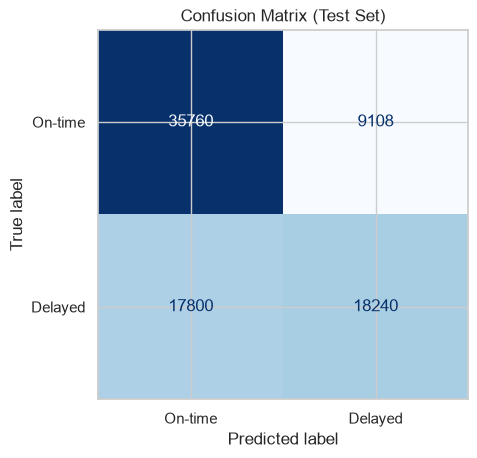

In [19]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=[config.CLASS_LABELS[0], config.CLASS_LABELS[1]],
    cmap="Blues", colorbar=False,
)
plt.title("Confusion Matrix (Test Set)")
plt.show()

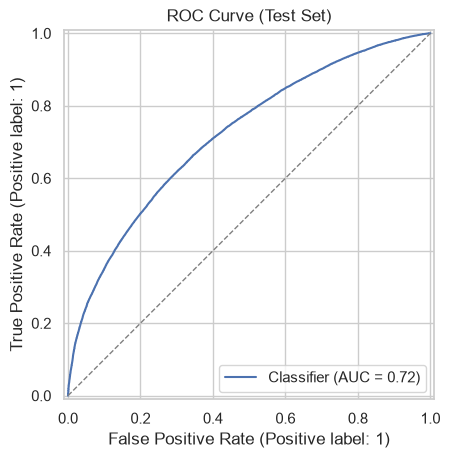

In [20]:
RocCurveDisplay.from_predictions(y_test, y_test_proba)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.title("ROC Curve (Test Set)")
plt.show()

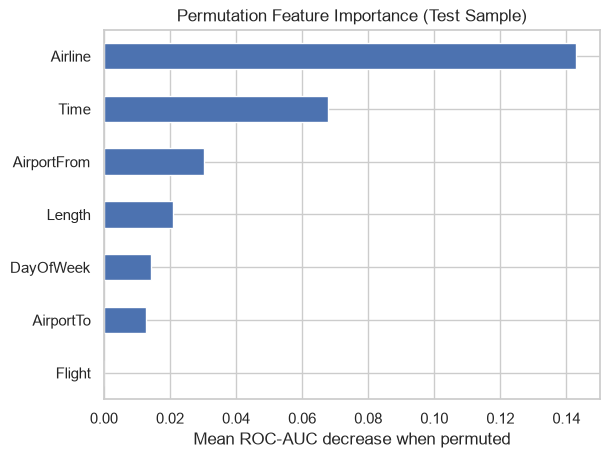

In [21]:
# Permutation importance on a subsample, in terms of the raw (pre-engineering) features
sample_idx = X_test.sample(n=min(20_000, len(X_test)), random_state=config.RANDOM_SEED).index
result = permutation_importance(
    best_pipeline, X_test.loc[sample_idx], y_test.loc[sample_idx],
    n_repeats=5, random_state=config.RANDOM_SEED, scoring="roc_auc", n_jobs=-1,
)
importances = pd.Series(result.importances_mean, index=X_test.columns).sort_values()
ax = importances.plot.barh(color="#4C72B0")
ax.set_xlabel("Mean ROC-AUC decrease when permuted")
ax.set_title("Permutation Feature Importance (Test Sample)")
plt.show()

## 10. Save the Model

The real training run (`python -m src.airline_delay.train`) already produced
`models/model.joblib` and `models/metadata.json` — those are what the API
actually serves. To avoid overwriting that production artifact with a
notebook rerun that may sample slightly differently, this cell saves to a
clearly separate `models/model_from_notebook.joblib` instead. Delete the
`if` guard below if you *do* want this notebook to replace the production
model.

In [22]:
from joblib import dump

notebook_model_path = config.MODELS_DIR / "model_from_notebook.joblib"
dump(best_pipeline, notebook_model_path)
print(f"Saved notebook-trained pipeline to {notebook_model_path}")
print(f"(Production model used by the API remains untouched at {config.MODEL_PATH})")

Saved notebook-trained pipeline to C:\development\claude-bde-airline\models\model_from_notebook.joblib
(Production model used by the API remains untouched at C:\development\claude-bde-airline\models\model.joblib)


## 11. Load the Production Model & Predict

This is exactly what `api/dependencies.py` does at API startup: load
`models/model.joblib` and `models/metadata.json`, then run predictions
through `predict.predict()`.

In [23]:
pipeline = predict.load_model()
metadata = predict.load_metadata()

print(f"Model: {metadata['model_name']}  (version {metadata['model_version']})")
print(f"Trained at: {metadata['trained_at_utc']}")
print("Test metrics at training time:")
pprint(metadata["test_metrics"])

Model: HistGradientBoostingClassifier  (version 20260717103554)
Trained at: 2026-07-17T10:35:54.159092+00:00
Test metrics at training time:
{'accuracy': 0.6674247293221931,
 'f1': 0.5755032498264656,
 'pr_auc': 0.6809493777130282,
 'precision': 0.6669591926283458,
 'recall': 0.5061043285238623,
 'roc_auc': 0.7205229760411029}


In [24]:
sample_records = test_df.sample(n=5, random_state=config.RANDOM_SEED)
# Only the columns the API actually accepts (config.RAW_FEATURE_COLUMNS).
# Note "Flight" is present in the raw dataset but deliberately excluded as a
# model feature -- see the permutation importance plot above, where it
# scored ~0.
records = sample_records[config.RAW_FEATURE_COLUMNS].to_dict(orient="records")

predictions = predict.predict(pipeline, records)

comparison = pd.DataFrame(records)
comparison["actual_class"] = sample_records[config.TARGET_COLUMN].values
comparison["actual_label"] = comparison["actual_class"].map(config.CLASS_LABELS)
comparison["predicted_class"] = [p["predicted_class"] for p in predictions]
comparison["predicted_label"] = [p["predicted_label"] for p in predictions]
comparison["probability_delayed"] = [round(p["probability_delayed"], 3) for p in predictions]
comparison

,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,actual_class,actual_label,predicted_class,predicted_label,probability_delayed
0,585.0,55.0,XE,AUS,IAH,2,0,On-time,0,On-time,0.153
1,825.0,312.0,US,SFO,PHL,6,0,On-time,0,On-time,0.400
2,395.0,58.0,9E,MLU,MEM,7,0,On-time,0,On-time,0.196
3,1210.0,215.0,AA,DFW,FAT,6,1,Delayed,1,Delayed,0.542
4,905.0,65.0,WN,LAS,SNA,4,1,Delayed,1,Delayed,0.855


## 12. Try the FastAPI Service, In-Process

`api/main.py` defines the same `/health`, `/model/info`, `/predict`, and
`/predict/batch` endpoints served by `uvicorn`. Using FastAPI's `TestClient`
here calls that app directly in-process (no server needed) — handy for
exploring the API from a notebook.

In [25]:
from fastapi.testclient import TestClient
from api.main import app

with TestClient(app) as client:
    print("--- GET /health ---")
    pprint(client.get("/health").json())

    print("\n--- GET /model/info ---")
    pprint(client.get("/model/info").json())

    print("\n--- POST /predict ---")
    single_payload = records[0]
    pprint(single_payload)
    pprint(client.post("/predict", json=single_payload).json())

    print("\n--- POST /predict/batch ---")
    batch_response = client.post("/predict/batch", json={"records": records})
    pprint(batch_response.json())

C:\development\claude-bde-airline\venv\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


--- GET /health ---
{'model_loaded': True, 'status': 'ok'}

--- GET /model/info ---
{'class_labels': {'0': 'On-time', '1': 'Delayed'},
 'model_name': 'HistGradientBoostingClassifier',
 'model_version': '20260717103554',
 'raw_feature_schema': {'Airline': 'string (IATA carrier code)',
                        'AirportFrom': 'string (IATA airport code)',
                        'AirportTo': 'string (IATA airport code)',
                        'DayOfWeek': 'int (1=Monday .. 7=Sunday)',
                        'Length': 'float (flight duration in minutes)',
                        'Time': 'float (minutes since midnight, 0-1439)'},
 'test_metrics': {'accuracy': 0.6674247293221931,
                  'f1': 0.5755032498264656,
                  'pr_auc': 0.6809493777130282,
                  'precision': 0.6669591926283458,
                  'recall': 0.5061043285238623,
                  'roc_auc': 0.7205229760411029},
 'trained_at_utc': '2026-07-17T10:35:54.159092+00:00'}

--- POST /predict 

### Running it for real

To run the API as an actual HTTP server rather than in-process:

```bash
venv/Scripts/uvicorn api.main:app --reload
```

Then visit `http://127.0.0.1:8000/docs` for the interactive Swagger UI, or:

```bash
curl -X POST http://127.0.0.1:8000/predict \
  -H "Content-Type: application/json" \
  -d '{"Time": 1296, "Length": 141, "Airline": "DL", "AirportFrom": "ATL", "AirportTo": "HOU", "DayOfWeek": 1}'
```

See [README.md](../README.md) for the full setup, retraining, and Docker instructions.

## Summary

- Loaded and validated 539,382 flight records with no missing values.
- Explored class balance and how delay relates to time of day, day of week,
  and airline.
- Split the data 70/15/15 (stratified, random — no time column exists).
- Engineered `IsWeekend` and `TimeOfDayBucket`, then built two preprocessing
  strategies to handle the high-cardinality airport columns without one-hot
  blow-up.
- Trained and compared Logistic Regression, Random Forest, and
  HistGradientBoosting; the latter won on validation ROC-AUC.
- Quick-tuned the winner with `RandomizedSearchCV`, refit on train+val, and
  evaluated once on the held-out test set (ROC-AUC, F1, confusion matrix,
  ROC curve, permutation feature importance).
- Loaded the production model artifact and generated predictions the same
  way the API does.
- Exercised the FastAPI service's endpoints directly.

To retrain the production model from scratch: `python -m src.airline_delay.train`.
To regenerate metrics/plots without retraining: `python -m src.airline_delay.evaluate`.
